In [1]:
from pathlib import Path
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "data_audit"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text[:80] if text else "unknown"

def find_file(candidates, search_dirs):
    # Return the first existing path from candidate names and search directories
    for directory in search_dirs:
        for name in candidates:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidates} in {search_dirs}")

SEARCH_DIRS = [DATA_RAW]

FILES = {
    "descriptor": find_file(["Molecular_Descriptor.xlsx"], SEARCH_DIRS),
    "activity": find_file(["ERα_activity.xlsx", "ERa_activity.xlsx"], SEARCH_DIRS),
    "admet": find_file(["ADMET.xlsx"], SEARCH_DIRS),
    "descriptor_info": find_file(["molecular_descriptors_summary.xlsx"], SEARCH_DIRS),
}

# 1. Load Raw Data

In [3]:
desc_train = pd.read_excel(FILES["descriptor"], sheet_name="training")
desc_test = pd.read_excel(FILES["descriptor"], sheet_name="test")

activity_train = pd.read_excel(FILES["activity"], sheet_name="training")
activity_test = pd.read_excel(FILES["activity"], sheet_name="test")

admet_train = pd.read_excel(FILES["admet"], sheet_name="training")
admet_test = pd.read_excel(FILES["admet"], sheet_name="test")

descriptor_summary = pd.read_excel(FILES["descriptor_info"], sheet_name="Summary")
descriptor_detailed = pd.read_excel(FILES["descriptor_info"], sheet_name="Detailed")

data_shapes = pd.DataFrame({
    "object": [
        "desc_train", "desc_test", "activity_train", "activity_test",
        "admet_train", "admet_test", "descriptor_summary", "descriptor_detailed"
    ],
    "rows": [
        len(desc_train), len(desc_test), len(activity_train), len(activity_test),
        len(admet_train), len(admet_test), len(descriptor_summary), len(descriptor_detailed)
    ],
    "columns": [
        desc_train.shape[1], desc_test.shape[1], activity_train.shape[1], activity_test.shape[1],
        admet_train.shape[1], admet_test.shape[1], descriptor_summary.shape[1], descriptor_detailed.shape[1]
    ]
})

display(data_shapes)
data_shapes.to_csv(RESULTS_DIR / "raw_data_shapes.csv", index=False)


,object,rows,columns
0,desc_train,1974,730
1,desc_test,50,730
2,activity_train,1974,3
3,activity_test,50,3
4,admet_train,1974,6
5,admet_test,50,6
6,descriptor_summary,53,5
7,descriptor_detailed,863,4


In [4]:
print("Descriptor columns, first 10:")
print(desc_train.columns[:10].tolist())
print("\nActivity columns:")
print(activity_train.columns.tolist())
print("\nADMET columns:")
print(admet_train.columns.tolist())
print("\nDescriptor explanation columns:")
print("Summary:", descriptor_summary.columns.tolist())
print("Detailed:", descriptor_detailed.columns.tolist())

Descriptor columns, first 10:
['SMILES', 'nAcid', 'ALogP', 'ALogp2', 'AMR', 'apol', 'naAromAtom', 'nAromBond', 'nAtom', 'nHeavyAtom']

Activity columns:
['SMILES', 'IC50_nM', 'pIC50']

ADMET columns:
['SMILES', 'Caco-2', 'CYP3A4', 'hERG', 'HOB', 'MN']

Descriptor explanation columns:
Summary: ['Descriptor type', 'Number', 'Descriptor', 'Class', 'Reference']
Detailed: ['Descriptor Java Class', 'Descriptor', 'Description', 'Class']



# 2. Compound Alignment Checks

In [5]:

def smiles_alignment_report(split_name, desc_df, activity_df, admet_df):
    report = {
        "split": split_name,
        "n_desc_rows": len(desc_df),
        "n_activity_rows": len(activity_df),
        "n_admet_rows": len(admet_df),
        "desc_activity_same_order": desc_df["SMILES"].equals(activity_df["SMILES"]),
        "desc_admet_same_order": desc_df["SMILES"].equals(admet_df["SMILES"]),
        "activity_admet_same_order": activity_df["SMILES"].equals(admet_df["SMILES"]),
        "desc_unique_smiles": desc_df["SMILES"].nunique(),
        "activity_unique_smiles": activity_df["SMILES"].nunique(),
        "admet_unique_smiles": admet_df["SMILES"].nunique(),
        "desc_duplicate_smiles": int(desc_df["SMILES"].duplicated().sum()),
        "activity_duplicate_smiles": int(activity_df["SMILES"].duplicated().sum()),
        "admet_duplicate_smiles": int(admet_df["SMILES"].duplicated().sum()),
    }
    return report

alignment_df = pd.DataFrame([
    smiles_alignment_report("training", desc_train, activity_train, admet_train),
    smiles_alignment_report("test", desc_test, activity_test, admet_test),
])

display(alignment_df)
alignment_df.to_csv(RESULTS_DIR / "smiles_alignment_report.csv", index=False)


,split,n_desc_rows,n_activity_rows,n_admet_rows,desc_activity_same_order,desc_admet_same_order,activity_admet_same_order,desc_unique_smiles,activity_unique_smiles,admet_unique_smiles,desc_duplicate_smiles,activity_duplicate_smiles,admet_duplicate_smiles
0,training,1974,1974,1974,True,True,True,1974,1974,1974,0,0,0
1,test,50,50,50,True,True,True,50,50,50,0,0,0


# 3. Missing Values and Duplicate Rows

In [6]:
def missing_report(name, df):
    return {
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "total_missing_values": int(df.isna().sum().sum()),
        "columns_with_missing_values": int((df.isna().sum() > 0).sum()),
        "duplicate_rows": int(df.duplicated().sum())
    }

missing_df = pd.DataFrame([
    missing_report("desc_train", desc_train),
    missing_report("desc_test", desc_test),
    missing_report("activity_train", activity_train),
    missing_report("activity_test", activity_test),
    missing_report("admet_train", admet_train),
    missing_report("admet_test", admet_test),
])

display(missing_df)
missing_df.to_csv(RESULTS_DIR / "missing_and_duplicate_report.csv", index=False)

,table,rows,columns,total_missing_values,columns_with_missing_values,duplicate_rows
0,desc_train,1974,730,0,0,0
1,desc_test,50,730,0,0,0
2,activity_train,1974,3,0,0,0
3,activity_test,50,3,100,2,0
4,admet_train,1974,6,0,0,0
5,admet_test,50,6,250,5,0


In [7]:
# Save column-level missingness for transparency.
column_missing = []
for name, df in [
    ("desc_train", desc_train),
    ("activity_train", activity_train),
    ("admet_train", admet_train),
]:
    tmp = df.isna().sum().reset_index()
    tmp.columns = ["column", "missing_count"]
    tmp["table"] = name
    tmp["missing_rate"] = tmp["missing_count"] / len(df)
    column_missing.append(tmp)

column_missing_df = pd.concat(column_missing, ignore_index=True)
column_missing_df.to_csv(RESULTS_DIR / "column_missingness_training.csv", index=False)

display(column_missing_df.query("missing_count > 0").head(20))


,column,missing_count,table,missing_rate


# 4. Descriptor Matrix Audit

In [8]:
# Numeric Descriptor Checks
X_train = desc_train.drop(columns=["SMILES"])
X_test = desc_test.drop(columns=["SMILES"])

y_pIC50 = activity_train["pIC50"]
y_IC50 = activity_train["IC50_nM"]
Y_admet = admet_train.drop(columns=["SMILES"])

non_numeric_after_coercion = X_train.isna().sum()
non_numeric_after_coercion = non_numeric_after_coercion[non_numeric_after_coercion > 0].sort_values(ascending=False)

non_numeric_after_coercion.to_csv(RESULTS_DIR / "descriptor_non_numeric_or_missing_after_coercion.csv")

print("Number of descriptor columns with missing/non-numeric values after coercion:", len(non_numeric_after_coercion))
display(non_numeric_after_coercion.head(20))

Number of descriptor columns with missing/non-numeric values after coercion: 0


Series([], dtype: int64)

,descriptor_numeric_type,n_descriptors
1,continuous_float_like,359
0,binary_like,241
3,integer_low_cardinality,102
2,integer_count_like,27


,descriptor,pandas_dtype,n_unique_values,unique_value_ratio,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,min,max,mean,std,descriptor_numeric_type
0,nAcid,int64,5,0.002533,True,False,True,False,0.000000e+00,4.000000,0.108409,0.347812,integer_low_cardinality
1,ALogP,float64,1625,0.823202,False,False,False,True,-2.310500e+01,5.181700,1.110164,1.433887,continuous_float_like
2,ALogp2,float64,1623,0.822188,False,False,False,True,3.600000e-07,533.841025,3.288495,12.829666,continuous_float_like
3,AMR,float64,1631,0.826241,False,False,False,True,5.406700e+01,517.429400,116.557106,31.559459,continuous_float_like
4,apol,float64,1324,0.670719,False,False,False,True,3.066193e+01,359.662740,60.626471,19.444821,continuous_float_like
5,naAromAtom,int64,25,0.012665,True,False,False,False,0.000000e+00,30.000000,15.446809,5.154547,integer_count_like
6,nAromBond,int64,25,0.012665,True,False,False,False,0.000000e+00,34.000000,16.189463,5.633844,integer_count_like
7,nAtom,int64,87,0.044073,True,False,False,False,2.100000e+01,343.000000,50.761905,18.084599,integer_count_like
8,nHeavyAtom,int64,42,0.021277,True,False,False,False,1.400000e+01,163.000000,28.112462,8.071835,integer_count_like
9,nH,int64,61,0.030902,True,False,False,False,5.000000e+00,180.000000,22.649443,10.772761,integer_count_like


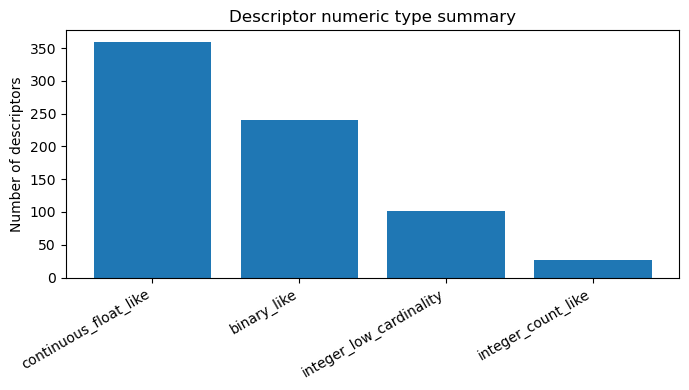

In [9]:
def is_integer_like(series, tol=1e-10):
    values = series.dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return False
    return bool(np.all(np.abs(values - np.round(values)) < tol))


descriptor_type_records = []

for col in X_train.columns:
    s = X_train[col]
    non_missing = s.dropna()
    unique_values = np.sort(non_missing.unique()) if len(non_missing) > 0 else np.array([])
    n_unique = int(len(unique_values))
    unique_ratio = n_unique / len(s) if len(s) > 0 else np.nan
    integer_like = is_integer_like(s)
    binary_like = n_unique <= 2 and set(unique_values).issubset({0, 1})
    low_cardinality = (n_unique <= 10) or (unique_ratio <= 0.01)
    continuous_like = (not integer_like) and (not binary_like)

    descriptor_type_records.append({
        "descriptor": col,
        "pandas_dtype": str(X_train[col].dtype),
        "n_unique_values": n_unique,
        "unique_value_ratio": unique_ratio,
        "is_integer_like": integer_like,
        "is_binary_like": binary_like,
        "is_low_cardinality": low_cardinality,
        "is_continuous_like": continuous_like,
        "min": float(non_missing.min()) if len(non_missing) > 0 else np.nan,
        "max": float(non_missing.max()) if len(non_missing) > 0 else np.nan,
        "mean": float(non_missing.mean()) if len(non_missing) > 0 else np.nan,
        "std": float(non_missing.std(ddof=0)) if len(non_missing) > 0 else np.nan,
    })

descriptor_type_audit = pd.DataFrame(descriptor_type_records)

descriptor_type_audit["descriptor_numeric_type"] = np.select(
    [
        descriptor_type_audit["is_binary_like"],
        descriptor_type_audit["is_integer_like"] & descriptor_type_audit["is_low_cardinality"],
        descriptor_type_audit["is_integer_like"] & (~descriptor_type_audit["is_low_cardinality"]),
        descriptor_type_audit["is_continuous_like"],
    ],
    [
        "binary_like",
        "integer_low_cardinality",
        "integer_count_like",
        "continuous_float_like",
    ],
    default="other_numeric",
)

descriptor_type_audit.to_csv(RESULTS_DIR / "descriptor_numeric_type_audit.csv", index=False)

type_summary = (
    descriptor_type_audit
    .groupby("descriptor_numeric_type")
    .agg(n_descriptors=("descriptor", "count"))
    .reset_index()
    .sort_values("n_descriptors", ascending=False)
)

type_summary.to_csv(RESULTS_DIR / "descriptor_numeric_type_summary.csv", index=False)

display(type_summary)
display(descriptor_type_audit.head(20))

plt.figure(figsize=(7, 4))
plt.bar(type_summary["descriptor_numeric_type"], type_summary["n_descriptors"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of descriptors")
plt.title("Descriptor numeric type summary")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "descriptor_numeric_type_summary.png", dpi=200)
plt.show()

In [10]:
# Constant and Near-Constant Descriptor Audit
descriptor_variance = X_train.var(axis=0, ddof=0)
descriptor_std = X_train.std(axis=0, ddof=0)
descriptor_range = X_train.max(axis=0) - X_train.min(axis=0)

variability_records = []

for col in X_train.columns:
    vc = X_train[col].value_counts(dropna=False, normalize=True)
    dominant_value = vc.index[0]
    dominant_ratio = float(vc.iloc[0])
    n_unique = int(X_train[col].nunique(dropna=False))
    unique_ratio = n_unique / len(X_train)

    variability_records.append({
        "descriptor": col,
        "variance": float(descriptor_variance[col]),
        "std": float(descriptor_std[col]),
        "range": float(descriptor_range[col]),
        "n_unique_values": n_unique,
        "unique_value_ratio": unique_ratio,
        "dominant_value": dominant_value,
        "dominant_value_ratio": dominant_ratio,
        "is_constant": bool(descriptor_variance[col] <= 1e-12),
        "dominant_value_ge_90pct": bool(dominant_ratio >= 0.90),
        "dominant_value_ge_95pct": bool(dominant_ratio >= 0.95),
        "unique_ratio_le_1pct": bool(unique_ratio <= 0.01),
    })

descriptor_variability = pd.DataFrame(variability_records)

descriptor_variability["is_near_constant"] = (
    (~descriptor_variability["is_constant"]) &
    (
        descriptor_variability["dominant_value_ge_95pct"] |
        descriptor_variability["unique_ratio_le_1pct"]
    )
)

descriptor_variability = descriptor_variability.merge(
    descriptor_type_audit[[
        "descriptor",
        "descriptor_numeric_type",
        "is_integer_like",
        "is_binary_like",
        "is_low_cardinality",
        "is_continuous_like",
    ]],
    on="descriptor",
    how="left",
)

descriptor_variability = descriptor_variability.sort_values(
    ["is_constant", "is_near_constant", "dominant_value_ratio"],
    ascending=[False, False, False],
)

descriptor_variability["is_rare_binary_like"] = (
    descriptor_variability["is_binary_like"].fillna(False).astype(bool)
    & (~descriptor_variability["is_constant"].fillna(False).astype(bool))
    & (descriptor_variability["dominant_value_ratio"].fillna(0) >= 0.95)
)

descriptor_variability.to_csv(RESULTS_DIR / "descriptor_variability_audit.csv", index=False)

constant_descriptors = descriptor_variability.loc[descriptor_variability["is_constant"], "descriptor"].tolist()
near_constant_descriptors = descriptor_variability.loc[descriptor_variability["is_near_constant"], "descriptor"].tolist()

pd.DataFrame({"descriptor": constant_descriptors}).to_csv(RESULTS_DIR / "constant_descriptors.csv", index=False)
pd.DataFrame({"descriptor": near_constant_descriptors}).to_csv(RESULTS_DIR / "near_constant_descriptors.csv", index=False)

print("Number of constant descriptors:", len(constant_descriptors))
print("Number of near-constant descriptors:", len(near_constant_descriptors))
print("Number of descriptors with dominant value >= 90%:", int(descriptor_variability["dominant_value_ge_90pct"].sum()))
print("Number of descriptors with dominant value >= 95%:", int(descriptor_variability["dominant_value_ge_95pct"].sum()))

display(descriptor_variability.head(30))

Number of constant descriptors: 225
Number of near-constant descriptors: 184
Number of descriptors with dominant value >= 90%: 367
Number of descriptors with dominant value >= 95%: 326


,descriptor,variance,std,range,n_unique_values,unique_value_ratio,dominant_value,dominant_value_ratio,is_constant,dominant_value_ge_90pct,dominant_value_ge_95pct,unique_ratio_le_1pct,is_near_constant,descriptor_numeric_type,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,is_rare_binary_like
10,nB,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
51,nBondsQ,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
125,nHsNH3p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
126,nHssNH2p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
127,nHsssNHp,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
137,nHmisc,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
138,nsLi,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
139,nssBe,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
140,nssssBem,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False
141,nsBH2,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False


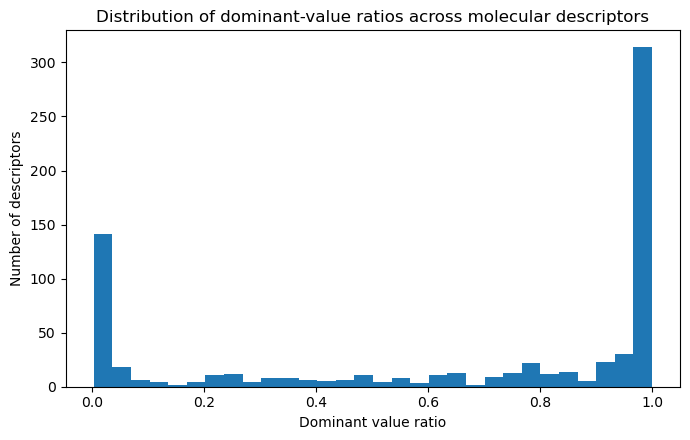

In [11]:
# Histogram of dominant-value ratios
plt.figure(figsize=(7, 4.5))
plt.hist(descriptor_variability["dominant_value_ratio"], bins=30)
plt.xlabel("Dominant value ratio")
plt.ylabel("Number of descriptors")
plt.title("Distribution of dominant-value ratios across molecular descriptors")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "descriptor_dominant_value_ratio_histogram.png", dpi=200)
plt.show()

In [12]:
# Descriptor Category Mapping

def build_descriptor_category_map_from_summary(summary_df):
    # Build descriptor-to-category mapping using Summary sheet with descriptor lists
    records = []
    for _, row in summary_df.iterrows():
        category = str(row["Descriptor type"]).strip()
        descriptor_list = str(row["Descriptor"]).strip()
        if not descriptor_list or descriptor_list.lower() == "nan":
            continue
        descriptors = [d.strip() for d in descriptor_list.split(",")]
        for d in descriptors:
            if d:
                records.append({
                    "descriptor": d,
                    "descriptor_category": category,
                    "descriptor_category_source": "Summary.Descriptor type",
                })

    mapping = pd.DataFrame(records).drop_duplicates(subset=["descriptor"])
    return mapping


def build_descriptor_category_map_from_detailed(detailed_df):
    # Prefer Descriptor Java Class with forward filling; otherwise use Class.
    detailed_df["descriptor_category"] = detailed_df["Descriptor Java Class"].ffill().astype(str).str.strip()
    source = "Detailed.Descriptor Java Class"

    mapping = detailed_df[["Descriptor", "descriptor_category"]].copy()
    mapping.columns = ["descriptor", "descriptor_category"]
    mapping["descriptor"] = mapping["descriptor"].astype(str).str.strip()
    mapping["descriptor_category_source"] = source
    mapping = mapping.drop_duplicates(subset=["descriptor"])
    return mapping


summary_mapping = build_descriptor_category_map_from_summary(descriptor_summary)
detailed_mapping = build_descriptor_category_map_from_detailed(descriptor_detailed)

# Use Summary mapping first, then fill unmatched descriptors with Detailed mapping if available
descriptor_category_map = pd.DataFrame({"descriptor": X_train.columns})

if summary_mapping is not None:
    descriptor_category_map = descriptor_category_map.merge(summary_mapping, on="descriptor", how="left")
else:
    descriptor_category_map["descriptor_category"] = np.nan
    descriptor_category_map["descriptor_category_source"] = np.nan

if detailed_mapping is not None:
    detailed_lookup = detailed_mapping.set_index("descriptor")[["descriptor_category", "descriptor_category_source"]]
    missing_mask = descriptor_category_map["descriptor_category"].isna()
    descriptor_category_map.loc[missing_mask, "descriptor_category"] = descriptor_category_map.loc[missing_mask, "descriptor"].map(detailed_lookup["descriptor_category"])
    descriptor_category_map.loc[missing_mask, "descriptor_category_source"] = descriptor_category_map.loc[missing_mask, "descriptor"].map(detailed_lookup["descriptor_category_source"])

# Remaining unmatched descriptors
descriptor_category_map["descriptor_category"] = descriptor_category_map["descriptor_category"].fillna("Unknown")
descriptor_category_map["descriptor_category_source"] = descriptor_category_map["descriptor_category_source"].fillna("Unmatched")

descriptor_category_map = descriptor_category_map.merge(
    descriptor_variability[["descriptor", "is_constant", "is_near_constant", "dominant_value_ratio"]],
    on="descriptor",
    how="left",
)

descriptor_category_map = descriptor_category_map.merge(
    descriptor_type_audit[[
        "descriptor",
        "descriptor_numeric_type",
        "is_integer_like",
        "is_binary_like",
        "is_low_cardinality",
        "is_continuous_like",
    ]],
    on="descriptor",
    how="left",
)

descriptor_category_map.to_csv(RESULTS_DIR / "descriptor_category_map.csv", index=False)

category_summary = (
    descriptor_category_map
    .groupby("descriptor_category")
    .agg(
        n_descriptors=("descriptor", "count"),
        n_constant=("is_constant", "sum"),
        n_near_constant=("is_near_constant", "sum"),
    )
    .reset_index()
)
category_summary["n_nonconstant"] = category_summary["n_descriptors"] - category_summary["n_constant"]
category_summary = category_summary.sort_values("n_descriptors", ascending=False)
category_summary.to_csv(RESULTS_DIR / "descriptor_category_summary.csv", index=False)

category_type_summary = (
    descriptor_category_map
    .groupby(["descriptor_category", "descriptor_numeric_type"])
    .agg(n_descriptors=("descriptor", "count"))
    .reset_index()
    .sort_values(["descriptor_category", "n_descriptors"], ascending=[True, False])
)
category_type_summary.to_csv(RESULTS_DIR / "descriptor_category_numeric_type_summary.csv", index=False)

print("Number of descriptor categories:", descriptor_category_map["descriptor_category"].nunique())
print("Unmatched descriptors:", int((descriptor_category_map["descriptor_category"] == "Unknown").sum()))
display(category_summary.head(25))
display(category_type_summary.head(30))

Number of descriptor categories: 48
Unmatched descriptors: 0


,descriptor_category,n_descriptors,n_constant,n_near_constant,n_nonconstant
6,Atom type electrotopological state,488,218,115,270
21,Extended topochemical atom,43,0,2,43
36,Ring count,23,5,18,18
33,Molecular distance edge,19,0,4,19
17,Chi path,16,0,0,16
5,Atom count,14,1,9,13
37,RingCountDescriptor,11,0,11,11
15,Chi chain,10,0,4,10
13,Bond count,10,1,3,9
14,Carbon types,9,0,7,9


,descriptor_category,descriptor_numeric_type,n_descriptors
0,ALOGP,continuous_float_like,3
1,APol,continuous_float_like,1
2,Acidic group count,integer_low_cardinality,1
3,Aromatic atoms count,integer_count_like,1
4,Aromatic bonds count,integer_count_like,1
7,Atom count,integer_low_cardinality,8
6,Atom count,integer_count_like,4
5,Atom count,binary_like,2
8,Atom type electrotopological state,binary_like,229
9,Atom type electrotopological state,continuous_float_like,204


In [13]:
# Within-Category Descriptor Correlation Audit
CATEGORY_CORR_DIR = FIGURES_DIR / "within_category_descriptor_correlations"
CATEGORY_CORR_DIR.mkdir(parents=True, exist_ok=True)

corr_threshold = 0.90
X_corr_base = X_train.drop(columns=constant_descriptors, errors="ignore")


def fast_abs_pearson_corr(df):
    # Pearson correlation matrix
    arr = df.to_numpy(dtype=float)
    arr = arr - np.nanmean(arr, axis=0, keepdims=True)
    std = np.nanstd(arr, axis=0, ddof=0, keepdims=True)
    std[std == 0] = np.nan
    z = arr / std
    z = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
    corr = (z.T @ z) / max(z.shape[0], 1)
    corr = np.clip(corr, -1, 1)
    return np.abs(corr)


within_category_records = []
within_category_high_corr_records = []

for category, group in descriptor_category_map.groupby("descriptor_category"):
    descriptors_in_category = [d for d in group["descriptor"].tolist() if d in X_corr_base.columns]
    n_desc = len(descriptors_in_category)

    if n_desc < 2:
        within_category_records.append({
            "descriptor_category": category,
            "n_nonconstant_descriptors": n_desc,
            "n_descriptor_pairs": 0,
            "mean_abs_pearson_corr": np.nan,
            "median_abs_pearson_corr": np.nan,
            "max_abs_pearson_corr": np.nan,
            "n_pairs_abs_pearson_corr_ge_090": 0,
            "prop_pairs_abs_pearson_corr_ge_090": np.nan,
            "mean_abs_spearman_corr": np.nan,
            "median_abs_spearman_corr": np.nan,
            "max_abs_spearman_corr": np.nan,
            "n_pairs_abs_spearman_corr_ge_090": np.nan,
        })
        continue

    pearson_abs_array = fast_abs_pearson_corr(X_corr_base[descriptors_in_category])
    upper_mask = np.triu(np.ones(pearson_abs_array.shape, dtype=bool), k=1)
    pearson_upper = pearson_abs_array[upper_mask]

    n_pairs = len(pearson_upper)
    n_high_pearson = int((pearson_upper >= corr_threshold).sum())

    spearman_abs_array = X_corr_base[descriptors_in_category].corr(method="spearman").abs().to_numpy()
    spearman_upper = spearman_abs_array[upper_mask]
    mean_abs_spearman = float(np.nanmean(spearman_upper))
    median_abs_spearman = float(np.nanmedian(spearman_upper))
    max_abs_spearman = float(np.nanmax(spearman_upper))
    n_high_spearman = int(np.nansum(spearman_upper >= corr_threshold))

    within_category_records.append({
        "descriptor_category": category,
        "n_nonconstant_descriptors": n_desc,
        "n_descriptor_pairs": n_pairs,
        "mean_abs_pearson_corr": float(np.nanmean(pearson_upper)),
        "median_abs_pearson_corr": float(np.nanmedian(pearson_upper)),
        "max_abs_pearson_corr": float(np.nanmax(pearson_upper)),
        "n_pairs_abs_pearson_corr_ge_090": n_high_pearson,
        "prop_pairs_abs_pearson_corr_ge_090": n_high_pearson / n_pairs if n_pairs > 0 else np.nan,
        "mean_abs_spearman_corr": mean_abs_spearman,
        "median_abs_spearman_corr": median_abs_spearman,
        "max_abs_spearman_corr": max_abs_spearman,
        "n_pairs_abs_spearman_corr_ge_090": n_high_spearman,
    })

    # Save high-correlation pairs
    high_idx = np.argwhere((pearson_abs_array >= corr_threshold) & upper_mask)
    if len(high_idx) > 0:
        high_vals = pearson_abs_array[high_idx[:, 0], high_idx[:, 1]]
        order = np.argsort(-high_vals)
        if len(order) > 1000:
            order = order[:1000]
        high_pairs = pd.DataFrame({
            "descriptor_1": [descriptors_in_category[i] for i in high_idx[order, 0]],
            "descriptor_2": [descriptors_in_category[j] for j in high_idx[order, 1]],
            "abs_pearson_corr": high_vals[order],
            "descriptor_category": category,
        })
        within_category_high_corr_records.append(high_pairs)

    # Save individual heatmaps for reasonably sized categories only
    if 2 <= n_desc <= 40:
        fig_size = max(4.5, min(10, n_desc * 0.45))
        plt.figure(figsize=(fig_size, fig_size))
        im = plt.imshow(pearson_abs_array, vmin=0, vmax=1, aspect="auto", cmap="PuBu")
        plt.colorbar(im, label="Absolute Pearson correlation")
        plt.title(f"{category}", fontsize=10)
        if n_desc <= 25:
            plt.xticks(range(n_desc), descriptors_in_category, rotation=90, fontsize=6)
            plt.yticks(range(n_desc), descriptors_in_category, fontsize=6)
        else:
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        output_path = CATEGORY_CORR_DIR / f"within_category_corr_{safe_filename(category)}.png"
        plt.savefig(output_path, dpi=200)
        plt.close()

within_category_corr_summary = pd.DataFrame(within_category_records)
within_category_corr_summary = within_category_corr_summary.sort_values(
    ["n_pairs_abs_pearson_corr_ge_090", "prop_pairs_abs_pearson_corr_ge_090"],
    ascending=[False, False],
)
within_category_corr_summary.to_csv(RESULTS_DIR / "within_category_correlation_summary_pearson_spearman.csv", index=False)

if len(within_category_high_corr_records) > 0:
    within_category_high_corr_pairs = pd.concat(within_category_high_corr_records, ignore_index=True)
else:
    within_category_high_corr_pairs = pd.DataFrame(columns=["descriptor_1", "descriptor_2", "abs_pearson_corr", "descriptor_category"])

within_category_high_corr_pairs = within_category_high_corr_pairs.sort_values("abs_pearson_corr", ascending=False)
within_category_high_corr_pairs.to_csv(RESULTS_DIR / "within_category_high_corr_pairs_abs_pearson_ge_090.csv", index=False)

display(within_category_corr_summary.head(25))
display(within_category_high_corr_pairs.head(25))

,descriptor_category,n_nonconstant_descriptors,n_descriptor_pairs,mean_abs_pearson_corr,median_abs_pearson_corr,max_abs_pearson_corr,n_pairs_abs_pearson_corr_ge_090,prop_pairs_abs_pearson_corr_ge_090,mean_abs_spearman_corr,median_abs_spearman_corr,max_abs_spearman_corr,n_pairs_abs_spearman_corr_ge_090
6,Atom type electrotopological state,270,36315,0.106464,0.049873,1.000000,332,0.009142,0.101338,0.053295,1.000000,444.0
17,Chi path,16,120,0.839988,0.853767,0.993559,45,0.375000,0.878166,0.884815,0.994110,51.0
21,Extended topochemical atom,43,903,0.329319,0.274599,0.999660,45,0.049834,0.344634,0.296044,1.000000,50.0
9,Autocorrelation (polarizability),5,10,0.976985,0.974744,0.996190,10,1.000000,0.976082,0.974022,0.996712,10.0
13,Bond count,9,36,0.434220,0.323518,0.991163,7,0.194444,0.406074,0.239720,0.988620,7.0
18,Chi path cluster,6,15,0.839060,0.793495,0.992261,6,0.400000,0.872225,0.822644,0.991428,6.0
8,Autocorrelation (mass),5,10,0.836696,0.894058,0.977866,5,0.500000,0.901895,0.900081,0.973654,5.0
5,Atom count,13,78,0.186049,0.061125,0.969994,4,0.051282,0.182463,0.089476,0.962488,4.0
27,Kappa shape indices,3,3,0.957465,0.969367,0.975895,3,1.000000,0.936479,0.958662,0.961739,2.0
15,Chi chain,10,45,0.416118,0.231938,1.000000,3,0.066667,0.408226,0.154590,1.000000,5.0


,descriptor_1,descriptor_2,abs_pearson_corr,descriptor_category
36,minsSH,maxHsSH,1.0,Atom type electrotopological state
40,nssssNp,maxssssNp,1.0,Atom type electrotopological state
28,nHsSH,nsSH,1.0,Atom type electrotopological state
30,nsSH,maxsSH,1.0,Atom type electrotopological state
31,nsSH,SHsSH,1.0,Atom type electrotopological state
32,maxHsSH,maxsSH,1.0,Atom type electrotopological state
33,nsSH,SsSH,1.0,Atom type electrotopological state
34,mindS,maxdS,1.0,Atom type electrotopological state
35,minsSH,maxsSH,1.0,Atom type electrotopological state
37,nsSH,minHsSH,1.0,Atom type electrotopological state


Panel categories: ['Chi path', 'Autocorrelation (polarizability)', 'Bond count', 'Chi path cluster', 'Autocorrelation (mass)', 'Atom count']


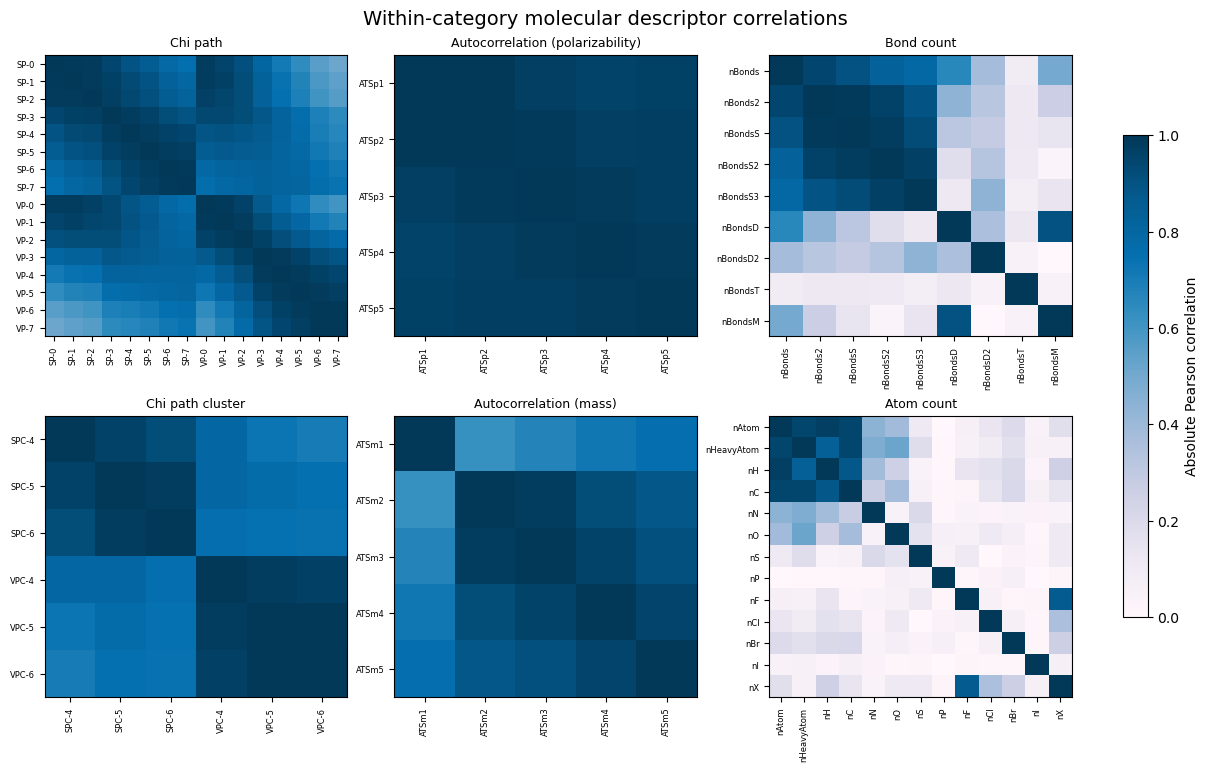

In [14]:
# Combined Within-Category Correlation Panel
panel_categories = (
    within_category_corr_summary
    .query("n_nonconstant_descriptors >= 2 and n_nonconstant_descriptors <= 20")
    .sort_values(["n_pairs_abs_pearson_corr_ge_090", "max_abs_pearson_corr", "n_nonconstant_descriptors"], ascending=[False, False, False])
    ["descriptor_category"]
    .head(6)
    .tolist()
)

print("Panel categories:", panel_categories)

if len(panel_categories) > 0:
    n_panels = len(panel_categories)
    n_cols = 3
    n_rows = math.ceil(n_panels / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)
    last_im = None

    for ax_idx, category in enumerate(panel_categories):
        ax = axes[ax_idx]
        descriptors_in_category = descriptor_category_map.loc[
            descriptor_category_map["descriptor_category"] == category,
            "descriptor",
        ].tolist()
        descriptors_in_category = [d for d in descriptors_in_category if d in X_corr_base.columns]
        corr_matrix = fast_abs_pearson_corr(X_corr_base[descriptors_in_category])

        last_im = ax.imshow(corr_matrix, vmin=0, vmax=1, aspect="auto", cmap="PuBu")
        ax.set_title(category, fontsize=9)

        n_desc = len(descriptors_in_category)
        ax.set_xticks(range(n_desc))
        ax.set_yticks(range(n_desc))
        ax.set_xticklabels(descriptors_in_category, rotation=90, fontsize=6)
        ax.set_yticklabels(descriptors_in_category, fontsize=6)

    for j in range(n_panels, len(axes)):
        axes[j].axis("off")

    if last_im is not None:
        fig.colorbar(last_im, ax=axes[:n_panels], shrink=0.75, label="Absolute Pearson correlation")
    fig.suptitle("Within-category molecular descriptor correlations", fontsize=14)

    panel_path = FIGURES_DIR / "within_category_descriptor_correlation_panel_top6.png"
    plt.savefig(panel_path, dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No categories available for panel plot.")

In [15]:
# Candidate Descriptor Groups for Later O2PLS-Inspired Analysis
#
# This section does NOT perform O2PLS.
# It prepares descriptor categories and possible descriptor groups.
#
# Standard O2PLS is a two-block method. Since this dataset contains
# one molecular descriptor matrix with many descriptor categories,
# we prepare chemically meaningful descriptor groups for possible
# later two-block analysis.

category_total_counts = (
    descriptor_category_map
    .groupby("descriptor_category")
    .agg(n_total_descriptors=("descriptor", "count"))
    .reset_index()
)

category_nonconstant_counts = (
    descriptor_category_map
    .query("is_constant == False")
    .groupby("descriptor_category")
    .agg(n_nonconstant_descriptors=("descriptor", "count"))
    .reset_index()
)

block_candidate_summary = category_total_counts.merge(
    category_nonconstant_counts,
    on="descriptor_category",
    how="left"
)

block_candidate_summary["n_nonconstant_descriptors"] = (
    block_candidate_summary["n_nonconstant_descriptors"]
    .fillna(0)
    .astype(int)
)

block_candidate_summary["n_constant_descriptors"] = (
    block_candidate_summary["n_total_descriptors"] -
    block_candidate_summary["n_nonconstant_descriptors"]
)

block_candidate_summary = block_candidate_summary.sort_values(
    "n_nonconstant_descriptors",
    ascending=False
)

block_candidate_summary.to_csv(
    RESULTS_DIR / "candidate_descriptor_groups_for_o2pls_inspired_analysis.csv",
    index=False
)

display(block_candidate_summary)

,descriptor_category,n_total_descriptors,n_nonconstant_descriptors,n_constant_descriptors
6,Atom type electrotopological state,488,270,218
21,Extended topochemical atom,43,43,0
33,Molecular distance edge,19,19,0
36,Ring count,23,18,5
17,Chi path,16,16,0
5,Atom count,14,13,1
37,RingCountDescriptor,11,11,0
15,Chi chain,10,10,0
14,Carbon types,9,9,0
13,Bond count,10,9,1


In [16]:
# Construct candidate two-block pairs.
# Each row represents one possible O2PLS-inspired two-block comparison:
# block X = one descriptor category
# block Y = another descriptor category
#
# This only creates candidate pairs. The final pairs should be selected
# based on chemical meaning and sufficient numbers of nonconstant descriptors.

MIN_DESCRIPTORS_PER_BLOCK = 5

eligible_categories = (
    block_candidate_summary
    .query("n_nonconstant_descriptors >= @MIN_DESCRIPTORS_PER_BLOCK")
    ["descriptor_category"]
    .tolist()
)

pair_records = []

for i, cat_x in enumerate(eligible_categories):
    for cat_y in eligible_categories[i + 1:]:
        n_x = int(
            block_candidate_summary.loc[
                block_candidate_summary["descriptor_category"] == cat_x,
                "n_nonconstant_descriptors"
            ].iloc[0]
        )
        n_y = int(
            block_candidate_summary.loc[
                block_candidate_summary["descriptor_category"] == cat_y,
                "n_nonconstant_descriptors"
            ].iloc[0]
        )
        
        pair_records.append({
            "block_x_category": cat_x,
            "block_y_category": cat_y,
            "n_descriptors_x": n_x,
            "n_descriptors_y": n_y,
            "candidate_use": "pairwise_two_block_analysis"
        })

candidate_two_block_pairs = pd.DataFrame(pair_records)

candidate_two_block_pairs.to_csv(
    RESULTS_DIR / "candidate_pairwise_descriptor_blocks_for_o2pls_inspired_analysis.csv",
    index=False
)

display(candidate_two_block_pairs.head(30))

,block_x_category,block_y_category,n_descriptors_x,n_descriptors_y,candidate_use
0,Atom type electrotopological state,Extended topochemical atom,270,43,pairwise_two_block_analysis
1,Atom type electrotopological state,Molecular distance edge,270,19,pairwise_two_block_analysis
2,Atom type electrotopological state,Ring count,270,18,pairwise_two_block_analysis
3,Atom type electrotopological state,Chi path,270,16,pairwise_two_block_analysis
4,Atom type electrotopological state,Atom count,270,13,pairwise_two_block_analysis
5,Atom type electrotopological state,RingCountDescriptor,270,11,pairwise_two_block_analysis
6,Atom type electrotopological state,Chi chain,270,10,pairwise_two_block_analysis
7,Atom type electrotopological state,Carbon types,270,9,pairwise_two_block_analysis
8,Atom type electrotopological state,Bond count,270,9,pairwise_two_block_analysis
9,Atom type electrotopological state,Chi cluster,270,8,pairwise_two_block_analysis


In [17]:
# Manual Chemically Meaningful Super-Blocks for Later O2PLS-Inspired Analysis

local_electronic_atom_environment_categories = [
    "Atom type electrotopological state",
    "Extended topochemical atom",
    "Autocorrelation (charge)",
    "Autocorrelation (polarizability)",
    "BCUT",
    "Molecular linear free energy relation",
]

topological_connectivity_structure_categories = [
    "Molecular distance edge",
    "Chi path",
    "Chi chain",
    "Chi cluster",
    "Chi path cluster",
    "Ring count",
    "RingCountDescriptor",
    "Atom count",
    "Bond count",
    "Carbon types",
    "Weighted path",
    "Autocorrelation (mass)",
]

known_categories = set(descriptor_category_map["descriptor_category"].unique())

missing_local_categories = [
    c for c in local_electronic_atom_environment_categories
    if c not in known_categories
]

missing_topological_categories = [
    c for c in topological_connectivity_structure_categories
    if c not in known_categories
]

print("Missing local/electronic categories:", missing_local_categories)
print("Missing topological/connectivity categories:", missing_topological_categories)

descriptor_category_map["candidate_super_block"] = "not_assigned"

descriptor_category_map.loc[
    descriptor_category_map["descriptor_category"].isin(local_electronic_atom_environment_categories),
    "candidate_super_block"
] = "block_X_local_electronic_atom_environment"

descriptor_category_map.loc[
    descriptor_category_map["descriptor_category"].isin(topological_connectivity_structure_categories),
    "candidate_super_block"
] = "block_Y_topological_connectivity_structure"

candidate_super_block_summary = (
    descriptor_category_map
    .assign(is_nonconstant=(descriptor_category_map["is_constant"] == False))
    .groupby("candidate_super_block")
    .agg(
        n_total_descriptors=("descriptor", "count"),
        n_nonconstant_descriptors=("is_nonconstant", "sum"),
        n_descriptor_categories=("descriptor_category", "nunique")
    )
    .reset_index()
)

candidate_super_block_summary.to_csv(
    RESULTS_DIR / "candidate_super_blocks_for_o2pls_inspired_analysis.csv",
    index=False
)

descriptor_category_map.to_csv(
    RESULTS_DIR / "descriptor_category_map_with_candidate_super_blocks.csv",
    index=False
)

display(candidate_super_block_summary)
display(
    descriptor_category_map[
        ["descriptor", "descriptor_category", "candidate_super_block", "is_constant", "descriptor_numeric_type"]
    ].head(30)
)

Missing local/electronic categories: []
Missing topological/connectivity categories: []


,candidate_super_block,n_total_descriptors,n_nonconstant_descriptors,n_descriptor_categories
0,block_X_local_electronic_atom_environment,553,335,6
1,block_Y_topological_connectivity_structure,136,129,12
2,not_assigned,40,40,30


,descriptor,descriptor_category,candidate_super_block,is_constant,descriptor_numeric_type
0,nAcid,Acidic group count,not_assigned,False,integer_low_cardinality
1,ALogP,ALOGP,not_assigned,False,continuous_float_like
2,ALogp2,ALOGP,not_assigned,False,continuous_float_like
3,AMR,ALOGP,not_assigned,False,continuous_float_like
4,apol,APol,not_assigned,False,continuous_float_like
5,naAromAtom,Aromatic atoms count,not_assigned,False,integer_count_like
6,nAromBond,Aromatic bonds count,not_assigned,False,integer_count_like
7,nAtom,Atom count,block_Y_topological_connectivity_structure,False,integer_count_like
8,nHeavyAtom,Atom count,block_Y_topological_connectivity_structure,False,integer_count_like
9,nH,Atom count,block_Y_topological_connectivity_structure,False,integer_count_like


# 5. Compound-Level Outlier Audit

In [18]:
# Base matrix for outlier audit: remove constant descriptors
X_outlier_base = X_train.drop(columns=constant_descriptors, errors="ignore").copy()
X_outlier_base = X_outlier_base.apply(pd.to_numeric, errors="coerce")

Compounds with at least one descriptor-level outlier: 1512


,SMILES,n_univariate_outlier_descriptors,prop_univariate_outlier_descriptors
1562,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,145,0.589431
1567,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,124,0.504065
1568,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,119,0.483740
1564,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C\C=C\C[C@H](NC(...,119,0.483740
1563,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C\C=C/C[C@H](NC(...,119,0.483740
1566,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)...,114,0.463415
1565,CC[C@H](C)[C@H](NC(=O)C(CC)NC(=O)[C@@H](N)CCCN...,113,0.459350
1416,Cn1cc(NC(=O)c2cc(NC(=O)CCS(=O)(=O)C)cn2C)cc1C(...,69,0.280488
1110,OCC1=Nc2cc3CCC(N(CC#C)c4ccc(cc4)C(=O)N[C@@H](C...,36,0.146341
963,C[C@]12CC[C@H]3[C@@H](CC[C@H]4[C@H]5CCC[C@@]34...,34,0.138211


,descriptor,n_outlier_compounds,prop_outlier_compounds
29,BCUTc-1l,652,0.330294
107,SdssC,489,0.247720
115,minHsOH,457,0.231510
138,maxsOH,440,0.222898
130,maxHsOH,427,0.216312
124,minsOH,426,0.215805
122,mindssC,409,0.207194
28,BCUTw-1h,291,0.147416
215,MDEO-11,265,0.134245
123,minaasC,225,0.113982


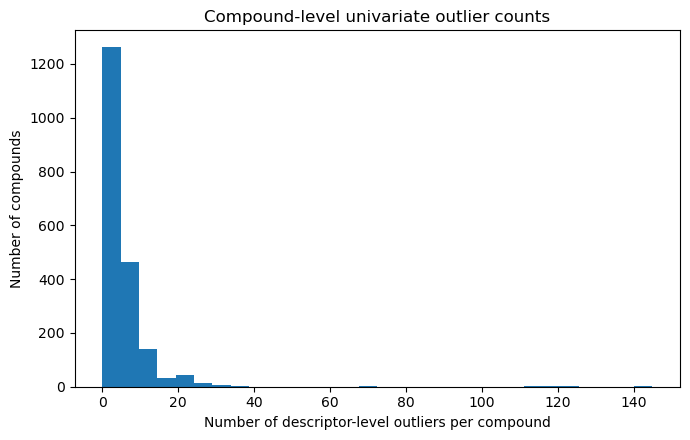

In [19]:
# Univariate robust outlier counts using modified z-scores
median = X_outlier_base.median(axis=0)
mad = (X_outlier_base - median).abs().median(axis=0)
mad_nonzero_cols = mad[mad > 0].index.tolist()

modified_z = pd.DataFrame(
    0.6745 * (X_outlier_base[mad_nonzero_cols] - median[mad_nonzero_cols]) / mad[mad_nonzero_cols],
    index=X_outlier_base.index,
    columns=mad_nonzero_cols,
)

univariate_outlier_mask = modified_z.abs() > 3.5

compound_univariate_outlier_summary = pd.DataFrame({
    "SMILES": desc_train['SMILES'],
    "n_univariate_outlier_descriptors": univariate_outlier_mask.sum(axis=1),
    "prop_univariate_outlier_descriptors": univariate_outlier_mask.mean(axis=1),
})
compound_univariate_outlier_summary = compound_univariate_outlier_summary.sort_values(
    "n_univariate_outlier_descriptors",
    ascending=False,
)
compound_univariate_outlier_summary.to_csv(RESULTS_DIR / "compound_univariate_outlier_summary_modified_z.csv", index=False)

descriptor_univariate_outlier_summary = pd.DataFrame({
    "descriptor": univariate_outlier_mask.columns,
    "n_outlier_compounds": univariate_outlier_mask.sum(axis=0).values,
    "prop_outlier_compounds": univariate_outlier_mask.mean(axis=0).values,
}).sort_values("n_outlier_compounds", ascending=False)
descriptor_univariate_outlier_summary.to_csv(RESULTS_DIR / "descriptor_univariate_outlier_summary_modified_z.csv", index=False)

print("Compounds with at least one descriptor-level outlier:", int((compound_univariate_outlier_summary["n_univariate_outlier_descriptors"] > 0).sum()))
display(compound_univariate_outlier_summary.head(20))
display(descriptor_univariate_outlier_summary.head(20))

plt.figure(figsize=(7, 4.5))
plt.hist(compound_univariate_outlier_summary["n_univariate_outlier_descriptors"], bins=30)
plt.xlabel("Number of descriptor-level outliers per compound")
plt.ylabel("Number of compounds")
plt.title("Compound-level univariate outlier counts")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "compound_univariate_outlier_count_histogram.png", dpi=200)
plt.show()

PCA components used for outlier audit: 20
Empirical T2 99% threshold: 129.8212815649294
Empirical SPE 99% threshold: 824.3322881834492
Flagged multivariate outliers: 36


,SMILES,T2_score,SPE_score,flag_T2_ge_empirical_99pct,flag_SPE_ge_empirical_99pct,flag_multivariate_outlier_empirical
1112,Cc1ccc(cc1)c2nnc(S)n2\N=C\C=C/c3ccccc3[N+](=O)...,1880.692682,366.905291,True,False,True
1562,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,1083.705595,2865.412157,True,True,True
1878,CCCCCCCCOC(=O)c1cc(I)c(O)c(I)c1,315.328971,2121.902600,True,True,True
1874,CCCCOC(=O)c1cc(I)c(O)c(I)c1,302.814532,2102.589850,True,True,True
1566,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cnc[nH]1)NC(=O)...,177.944082,648.146035,True,False,True
1567,CC[C@H](C)[C@@H]1NC(=O)[C@@H](CSSC[C@H](NC(=O)...,168.659879,635.610778,True,False,True
1563,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C\C=C/C[C@H](NC(...,167.643419,608.678957,True,False,True
1564,CC[C@H](C)[C@@H]1NC(=O)[C@@H](C\C=C\C[C@H](NC(...,167.643419,608.678957,True,False,True
1110,OCC1=Nc2cc3CCC(N(CC#C)c4ccc(cc4)C(=O)N[C@@H](C...,167.420528,497.926966,True,False,True
1865,Oc1ccc2C(=C(CCCc2c1F)c3ccc(OC(F)F)cc3F)c4ccc(O...,163.396348,271.720152,True,False,True


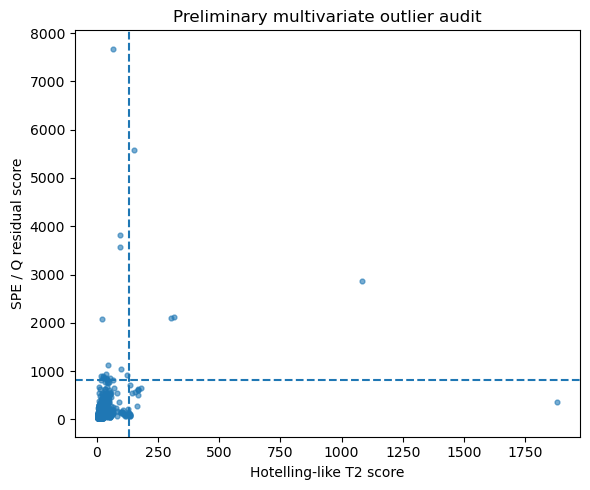

In [20]:
# PCA-based multivariate outlier audit

scaler_outlier = StandardScaler()
X_scaled_outlier = scaler_outlier.fit_transform(X_outlier_base)

n_pca_outlier_components = min(20, X_scaled_outlier.shape[0] - 1, X_scaled_outlier.shape[1])
pca_outlier = PCA(n_components=n_pca_outlier_components, svd_solver="randomized", random_state=42)
scores_outlier = pca_outlier.fit_transform(X_scaled_outlier)
X_reconstructed = pca_outlier.inverse_transform(scores_outlier)

# Hotelling-like T2 score in retained PCA space
t2_scores = np.sum((scores_outlier ** 2) / pca_outlier.explained_variance_, axis=1)

# Squared prediction error / Q residual
spe_scores = np.sum((X_scaled_outlier - X_reconstructed) ** 2, axis=1)

t2_threshold = np.quantile(t2_scores, 0.99)
spe_threshold = np.quantile(spe_scores, 0.99)

pca_outlier_summary = pd.DataFrame({
    "SMILES": desc_train['SMILES'],
    "T2_score": t2_scores,
    "SPE_score": spe_scores,
    "flag_T2_ge_empirical_99pct": t2_scores >= t2_threshold,
    "flag_SPE_ge_empirical_99pct": spe_scores >= spe_threshold,
})
pca_outlier_summary["flag_multivariate_outlier_empirical"] = (
    pca_outlier_summary["flag_T2_ge_empirical_99pct"] |
    pca_outlier_summary["flag_SPE_ge_empirical_99pct"]
)
pca_outlier_summary = pca_outlier_summary.sort_values(
    ["flag_multivariate_outlier_empirical", "T2_score", "SPE_score"],
    ascending=[False, False, False],
)
pca_outlier_summary.to_csv(RESULTS_DIR / "compound_pca_outlier_summary_empirical.csv", index=False)

print("PCA components used for outlier audit:", n_pca_outlier_components)
print("Empirical T2 99% threshold:", t2_threshold)
print("Empirical SPE 99% threshold:", spe_threshold)
print("Flagged multivariate outliers:", int(pca_outlier_summary["flag_multivariate_outlier_empirical"].sum()))
display(pca_outlier_summary.head(20))

plt.figure(figsize=(6, 5))
plt.scatter(t2_scores, spe_scores, s=12, alpha=0.6)
plt.axvline(t2_threshold, linestyle="--")
plt.axhline(spe_threshold, linestyle="--")
plt.xlabel("Hotelling-like T2 score")
plt.ylabel("SPE / Q residual score")
plt.title("Preliminary multivariate outlier audit")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_outlier_T2_SPE_scatter.png", dpi=200)
plt.show()

# 6. ERα Activity Audit

In [21]:
activity_summary = activity_train[["IC50_nM", "pIC50"]].describe().T
activity_summary["missing_count"] = activity_train[["IC50_nM", "pIC50"]].isna().sum()
activity_summary.to_csv(RESULTS_DIR / "er_activity_summary.csv")
display(activity_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count
IC50_nM,1974.0,9910.490039,105520.380714,0.046000,27.025000,262.500000,4148.125000,3.500000e+06,0
pIC50,1974.0,6.586112,1.423023,2.455932,5.382154,6.580871,7.568235,1.033724e+01,0


In [22]:
# Check pIC50 consistency assuming IC50 is measured in nM:
# pIC50 = -log10(IC50[M]) = -log10(IC50_nM * 1e-9)
positive_ic50 = activity_train["IC50_nM"] > 0
pIC50_from_ic50 = -np.log10(activity_train.loc[positive_ic50, "IC50_nM"] * 1e-9)
pIC50_diff = activity_train.loc[positive_ic50, "pIC50"] - pIC50_from_ic50

pIC50_consistency = pd.DataFrame({
    "metric": [
        "n_positive_IC50_values",
        "max_abs_difference_between_given_and_calculated_pIC50",
        "mean_abs_difference_between_given_and_calculated_pIC50"
    ],
    "value": [
        int(positive_ic50.sum()),
        float(np.max(np.abs(pIC50_diff))),
        float(np.mean(np.abs(pIC50_diff)))
    ]
})

pIC50_consistency.to_csv(RESULTS_DIR / "pIC50_consistency_check.csv", index=False)
display(pIC50_consistency)


,metric,value
0,n_positive_IC50_values,1.974000e+03
1,max_abs_difference_between_given_and_calculate...,2.486900e-14
2,mean_abs_difference_between_given_and_calculat...,2.572973e-15


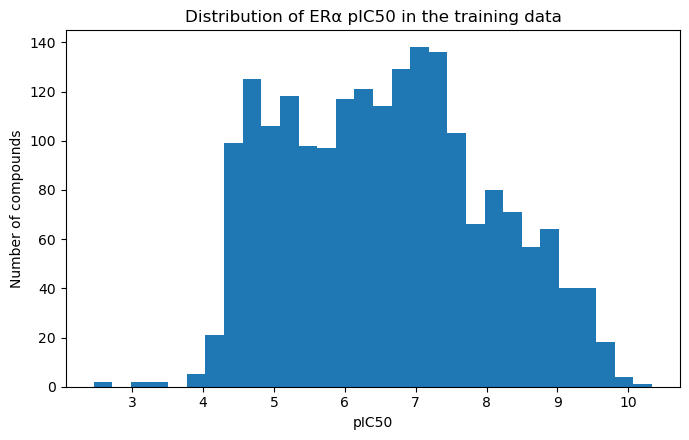

In [23]:
plt.figure(figsize=(7, 4.5))
plt.hist(activity_train["pIC50"].dropna(), bins=30)
plt.xlabel("pIC50")
plt.ylabel("Number of compounds")
plt.title("Distribution of ERα pIC50 in the training data")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pIC50_distribution.png", dpi=200)
plt.show()

In [24]:
# Activity endpoint outlier audit using the IQR rule

def iqr_outlier_flags(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    flags = (series < lower) | (series > upper)
    return lower, upper, flags

activity_outlier_summary = activity_train[["SMILES", "IC50_nM", "pIC50"]].copy()

for col in ["IC50_nM", "pIC50"]:
    lower, upper, flags = iqr_outlier_flags(activity_train[col])
    activity_outlier_summary[f"{col}_iqr_lower"] = lower
    activity_outlier_summary[f"{col}_iqr_upper"] = upper
    activity_outlier_summary[f"flag_{col}_iqr_outlier"] = flags.values

activity_outlier_summary.to_csv(
    RESULTS_DIR / "activity_outlier_summary_iqr.csv",
    index=False
)

print("pIC50 IQR outliers:", int(activity_outlier_summary["flag_pIC50_iqr_outlier"].sum()))
print("IC50 IQR outliers:", int(activity_outlier_summary["flag_IC50_nM_iqr_outlier"].sum()))

display(
    activity_outlier_summary[
        activity_outlier_summary["flag_pIC50_iqr_outlier"] |
        activity_outlier_summary["flag_IC50_nM_iqr_outlier"]
    ].head(20)
)

pIC50 IQR outliers: 0
IC50 IQR outliers: 309


,SMILES,IC50_nM,pIC50,IC50_nM_iqr_lower,IC50_nM_iqr_upper,flag_IC50_nM_iqr_outlier,pIC50_iqr_lower,pIC50_iqr_upper,flag_pIC50_iqr_outlier
70,Cc1cc(O)c2C(=O)c3c(O[C@@H]4O[C@H](CO)[C@@H](O)...,20000.0,4.698970,-6154.625,10329.775,True,2.103032,10.847357,False
106,Oc1ccc(cc1)C2=Nc3c(O)cc(O)cc3OC2,33000.0,4.481486,-6154.625,10329.775,True,2.103032,10.847357,False
150,Oc1ccc(cc1)C2=Nc3ccc(O)cc3OC2,16000.0,4.795880,-6154.625,10329.775,True,2.103032,10.847357,False
457,Oc1ccc(C(=O)Cc2oc3ccccc3c2)c(O)c1,85700.0,4.067019,-6154.625,10329.775,True,2.103032,10.847357,False
667,Oc1ccc2c(OC(=O)c3c(Cl)c(O)c(F)cc23)c1Cl,11600.0,4.935542,-6154.625,10329.775,True,2.103032,10.847357,False
697,Cc1c(O)ccc2c1OC(=O)c3c(C)c(N)ccc23,14300.0,4.844664,-6154.625,10329.775,True,2.103032,10.847357,False
704,Oc1ccc(cc1)N2C=Nc3cc(O)cc(O)c3C2=O,11097.0,4.954794,-6154.625,10329.775,True,2.103032,10.847357,False
706,Oc1cc(O)c2C(=O)N(C=Nc2c1)c3ccc(O)c(F)c3,44175.0,4.354823,-6154.625,10329.775,True,2.103032,10.847357,False
707,Oc1cc(O)c2C(=O)N(C=Nc2c1)c3ccc(O)c(Cl)c3,55015.0,4.259519,-6154.625,10329.775,True,2.103032,10.847357,False
709,COc1cc(O)c2C(=O)N(C=Nc2c1)c3ccc(O)cc3,25956.0,4.585762,-6154.625,10329.775,True,2.103032,10.847357,False


# 7. ADMET Endpoint Audit

In [25]:
admet_balance_records = []
for col in Y_admet.columns:
    counts = Y_admet[col].value_counts(dropna=False).to_dict()
    n_total = len(Y_admet)
    n_0 = int(counts.get(0, 0))
    n_1 = int(counts.get(1, 0))
    n_missing = int(Y_admet[col].isna().sum())
    admet_balance_records.append({
        "endpoint": col,
        "n_total": n_total,
        "n_0": n_0,
        "n_1": n_1,
        "n_missing": n_missing,
        "positive_rate": n_1 / n_total,
        "negative_rate": n_0 / n_total,
    })

admet_balance = pd.DataFrame(admet_balance_records)
admet_balance.to_csv(RESULTS_DIR / "admet_endpoint_balance.csv", index=False)
display(admet_balance)

,endpoint,n_total,n_0,n_1,n_missing,positive_rate,negative_rate
0,Caco-2,1974,1215,759,0,0.384498,0.615502
1,CYP3A4,1974,513,1461,0,0.740122,0.259878
2,hERG,1974,875,1099,0,0.556738,0.443262
3,HOB,1974,1465,509,0,0.257852,0.742148
4,MN,1974,460,1514,0,0.766971,0.233029


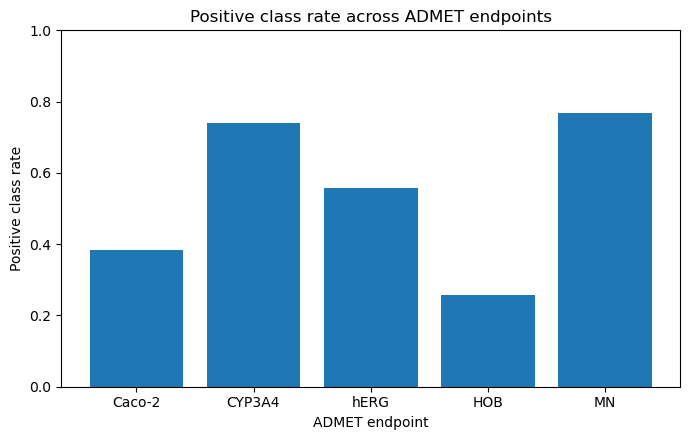

In [26]:
plt.figure(figsize=(7, 4.5))
plt.bar(admet_balance["endpoint"], admet_balance["positive_rate"])
plt.xlabel("ADMET endpoint")
plt.ylabel("Positive class rate")
plt.title("Positive class rate across ADMET endpoints")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "admet_positive_class_rates.png", dpi=200)
plt.show()

In [27]:
# Check whether ADMET endpoints are truly binary.

admet_invalid_records = []

for col in Y_admet.columns:
    observed_values = sorted(Y_admet[col].dropna().unique().tolist())
    invalid_values = [v for v in observed_values if v not in [0, 1]]
    
    admet_invalid_records.append({
        "endpoint": col,
        "observed_values": observed_values,
        "n_invalid_values": len(invalid_values),
        "invalid_values": invalid_values,
    })

admet_invalid_check = pd.DataFrame(admet_invalid_records)
admet_invalid_check.to_csv(
    RESULTS_DIR / "admet_invalid_label_check.csv",
    index=False
)

display(admet_invalid_check)

,endpoint,observed_values,n_invalid_values,invalid_values
0,Caco-2,"[0, 1]",0,[]
1,CYP3A4,"[0, 1]",0,[]
2,hERG,"[0, 1]",0,[]
3,HOB,"[0, 1]",0,[]
4,MN,"[0, 1]",0,[]


# 8. Descriptor Explanation Coverage

In [28]:
# Match descriptor columns to entries in the detailed explanation sheet

explained_descriptors = set(descriptor_detailed["Descriptor"].dropna().astype(str))
actual_descriptors = set(X_train.columns.astype(str))
matched_descriptors = sorted(actual_descriptors.intersection(explained_descriptors))
unmatched_descriptors = sorted(actual_descriptors.difference(explained_descriptors))

coverage_summary = pd.DataFrame({
    "metric": [
        "n_actual_descriptor_columns",
        "n_unique_descriptors_in_explanation_file",
        "n_matched_descriptors",
        "n_unmatched_descriptors",
        "coverage_rate"
    ],
    "value": [
        len(actual_descriptors),
        len(explained_descriptors),
        len(matched_descriptors),
        len(unmatched_descriptors),
        len(matched_descriptors) / len(actual_descriptors)
    ]
})

coverage_summary.to_csv(RESULTS_DIR / "descriptor_explanation_coverage_summary.csv", index=False)
pd.DataFrame({"descriptor": unmatched_descriptors}).to_csv(RESULTS_DIR / "unmatched_descriptor_names.csv", index=False)

display(coverage_summary)
print("Unmatched descriptors:")
print(unmatched_descriptors[:20])

,metric,value
0,n_actual_descriptor_columns,729.0
1,n_unique_descriptors_in_explanation_file,863.0
2,n_matched_descriptors,729.0
3,n_unmatched_descriptors,0.0
4,coverage_rate,1.0


Unmatched descriptors:
[]


# 9. Preprocessing Decisions for pca/pls

In [29]:
preprocessing_candidates = descriptor_variability.copy()

merge_cols = [
    "descriptor",
    "descriptor_category",
    "candidate_super_block"
]

preprocessing_candidates = preprocessing_candidates.merge(
    descriptor_category_map[merge_cols].drop_duplicates(subset=["descriptor"]),
    on="descriptor",
    how="left",
)

preprocessing_candidates["remove_before_pca_pls"] = preprocessing_candidates["is_constant"]

preprocessing_candidates["review_before_pca_pls"] = (
    (~preprocessing_candidates["remove_before_pca_pls"]) &
    (
        preprocessing_candidates["is_near_constant"] |
        preprocessing_candidates["dominant_value_ge_90pct"]
    )
)

preprocessing_candidates["recommended_action"] = np.select(
    [
        preprocessing_candidates["is_constant"],
        preprocessing_candidates["is_rare_binary_like"],
        preprocessing_candidates["is_near_constant"],
    ],
    [
        "remove_constant_descriptor",
        "retain_but_review_as_rare_binary_indicator",
        "review_in_sensitivity_analysis",
    ],
    default="retain_initially",
)

preprocessing_candidates = preprocessing_candidates.sort_values(
    ["remove_before_pca_pls", "review_before_pca_pls", "dominant_value_ratio"],
    ascending=[False, False, False],
)

preprocessing_candidates.to_csv(
    RESULTS_DIR / "descriptor_preprocessing_candidates.csv",
    index=False
)

display(preprocessing_candidates.head(30))

,descriptor,variance,std,range,n_unique_values,unique_value_ratio,dominant_value,dominant_value_ratio,is_constant,dominant_value_ge_90pct,dominant_value_ge_95pct,unique_ratio_le_1pct,is_near_constant,descriptor_numeric_type,is_integer_like,is_binary_like,is_low_cardinality,is_continuous_like,is_rare_binary_like,descriptor_category,candidate_super_block,remove_before_pca_pls,review_before_pca_pls,recommended_action
0,nB,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
1,nBondsQ,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Bond count,block_Y_topological_connectivity_structure,True,False,remove_constant_descriptor
2,nHsNH3p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
3,nHssNH2p,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
4,nHsssNHp,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
5,nHmisc,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
6,nsLi,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
7,nssBe,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
8,nssssBem,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor
9,nsBH2,0.0,0.0,0.0,1,0.000507,0.0,1.0,True,True,True,True,False,binary_like,True,True,True,False,False,Atom type electrotopological state,block_X_local_electronic_atom_environment,True,False,remove_constant_descriptor


# 10. Consolidated Data Audit Summary

In [30]:
summary_records = {
    "n_training_compounds": int(X_train.shape[0]),
    "n_test_compounds": int(X_test.shape[0]),
    "n_molecular_descriptors": int(X_train.shape[1]),
    "n_missing_values_descriptor_train": int(X_train.isna().sum().sum()),
    "n_missing_values_activity_train": int(activity_train.isna().sum().sum()),
    "n_missing_values_admet_train": int(admet_train.isna().sum().sum()),
    "descriptor_activity_train_aligned": bool(alignment_df.loc[0, "desc_activity_same_order"]),
    "descriptor_admet_train_aligned": bool(alignment_df.loc[0, "desc_admet_same_order"]),
    "n_constant_descriptors": int(len(constant_descriptors)),
    "n_near_constant_descriptors": int(len(near_constant_descriptors)),
    "n_descriptors_dominant_value_ge_90pct": int(descriptor_variability["dominant_value_ge_90pct"].sum()),
    "n_descriptors_dominant_value_ge_95pct": int(descriptor_variability["dominant_value_ge_95pct"].sum()),
    "n_binary_like_descriptors": int((descriptor_type_audit["descriptor_numeric_type"] == "binary_like").sum()),
    "n_integer_low_cardinality_descriptors": int((descriptor_type_audit["descriptor_numeric_type"] == "integer_low_cardinality").sum()),
    "n_integer_count_like_descriptors": int((descriptor_type_audit["descriptor_numeric_type"] == "integer_count_like").sum()),
    "n_continuous_float_like_descriptors": int((descriptor_type_audit["descriptor_numeric_type"] == "continuous_float_like").sum()),
    "n_descriptor_categories": int(descriptor_category_map["descriptor_category"].nunique()),
    "largest_descriptor_category": str(category_summary.iloc[0]["descriptor_category"]),
    "largest_descriptor_category_n_descriptors": int(category_summary.iloc[0]["n_descriptors"]),
    "n_within_category_high_corr_pairs_abs_pearson_ge_090": int(len(within_category_high_corr_pairs)),
    "n_compounds_flagged_univariate_outlier_any_descriptor": int((compound_univariate_outlier_summary["n_univariate_outlier_descriptors"] > 0).sum()),
    "n_compounds_flagged_pca_multivariate_outlier_empirical": int(pca_outlier_summary["flag_multivariate_outlier_empirical"].sum()),
}

if "pIC50" in activity_train.columns and "flag_pIC50_iqr_outlier" in activity_outlier_summary.columns:
    summary_records["n_pIC50_iqr_outliers"] = int(activity_outlier_summary["flag_pIC50_iqr_outlier"].sum())

if "IC50_nM" in activity_train.columns and "flag_IC50_nM_iqr_outlier" in activity_outlier_summary.columns:
    summary_records["n_IC50_nM_iqr_outliers"] = int(activity_outlier_summary["flag_IC50_nM_iqr_outlier"].sum())

audit_summary = pd.DataFrame([summary_records])
audit_summary.to_csv(RESULTS_DIR / "data_audit_summary.csv", index=False)

summary_records.update({
    "n_descriptors_assigned_to_candidate_super_blocks": int(
        (descriptor_category_map["candidate_super_block"] != "not_assigned").sum()
    ),
    "n_nonconstant_descriptors_assigned_to_candidate_super_blocks": int(
        (
            (descriptor_category_map["candidate_super_block"] != "not_assigned") &
            (descriptor_category_map["is_constant"] == False)
        ).sum()
    ),
    "candidate_super_block_names": "; ".join(
        sorted(
            descriptor_category_map.loc[
                descriptor_category_map["candidate_super_block"] != "not_assigned",
                "candidate_super_block"
            ].unique()
        )
    ),
})
    
display(audit_summary.T.rename(columns={0: "value"}))

,value
n_training_compounds,1974
n_test_compounds,50
n_molecular_descriptors,729
n_missing_values_descriptor_train,0
n_missing_values_activity_train,0
n_missing_values_admet_train,0
descriptor_activity_train_aligned,True
descriptor_admet_train_aligned,True
n_constant_descriptors,225
n_near_constant_descriptors,184
